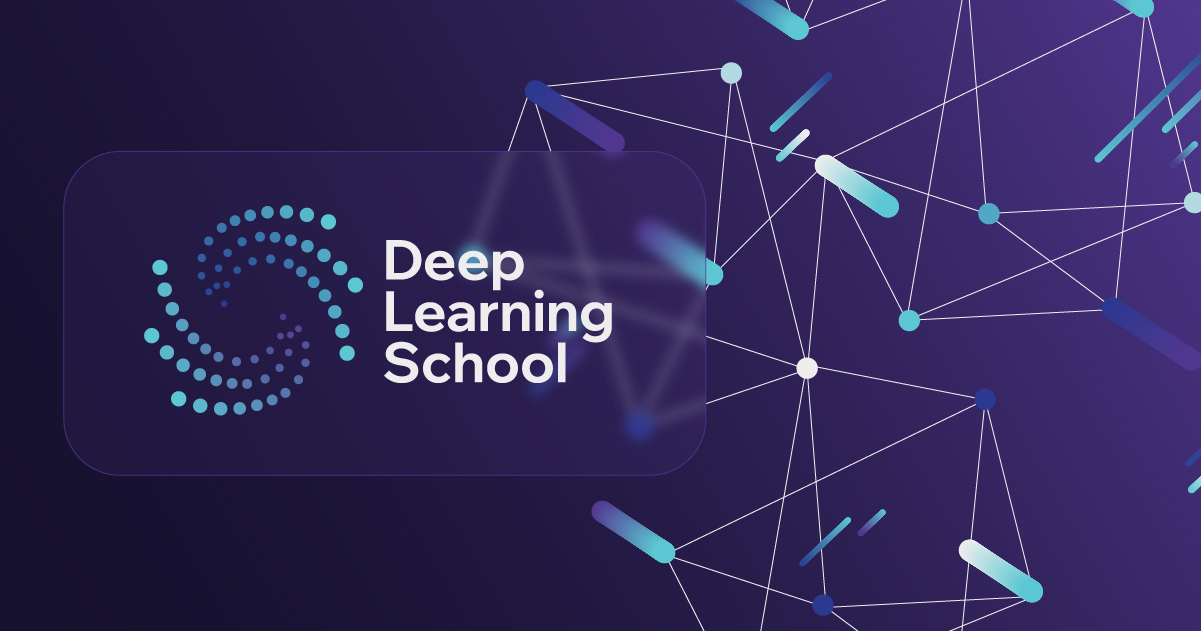

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

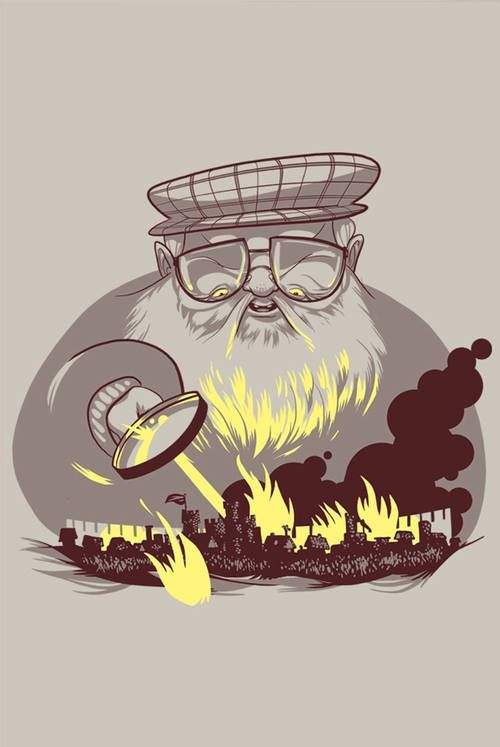

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **title**: Социальный статус или знатность

* **house**: Дом, к которому принадлежит персонаж

* **culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **isNoble**: Знатность персонажа, основанное на титуле

* **age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **spouse**: Имя супруги\а персонажа

* **father**: Имя отца персонажа

* **mother**: Имя матери персонажа

* **heir**: Имя наследника персонажа

* **isMarried**: Represents whether the character is married

* **isAliveSpouse**: Represents whether character's spouse is alive

* **isAliveMother** Жива ли мать персонажа

* **isAliveHeir** Жив ли наследник персонажа

* **isAliveFather** Указывает, жив ли отец персонажа

* **numDeadRelations** Количество умерших персонажей, с которыми персонаж связан

* **popularity** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.65$ --- 4 балла

3) $0.65 > score \geqslant 0.55$ --- 3 балла

4) $0.55 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.45$ --- 1 балл

6) $0.45 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [2558]:
#!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
#!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

#### **Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [2559]:

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

#### **Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [2560]:
data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No')
test = pd.read_csv("game_of_thrones_test.csv", index_col='S.No')
data

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Archmaester,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.160535,1
1554,Masha Heddle,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.040134,0
1555,Matthos Seaworth,NaN,1,NaN,NaN,NaN,NaN,NaN,House Seaworth,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.076923,0


#### **Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

In [2561]:
data.isna().sum()

name                   0
title                840
male                   0
culture             1069
dateOfBirth         1278
mother              1539
father              1535
heir                1536
house                381
spouse              1357
book1                  0
book2                  0
book3                  0
book4                  0
book5                  0
isAliveMother       1539
isAliveFather       1535
isAliveHeir         1536
isAliveSpouse       1357
isMarried              0
isNoble                0
age                 1278
numDeadRelations       0
popularity             0
isAlive                0
dtype: int64

<Axes: xlabel='S.No'>

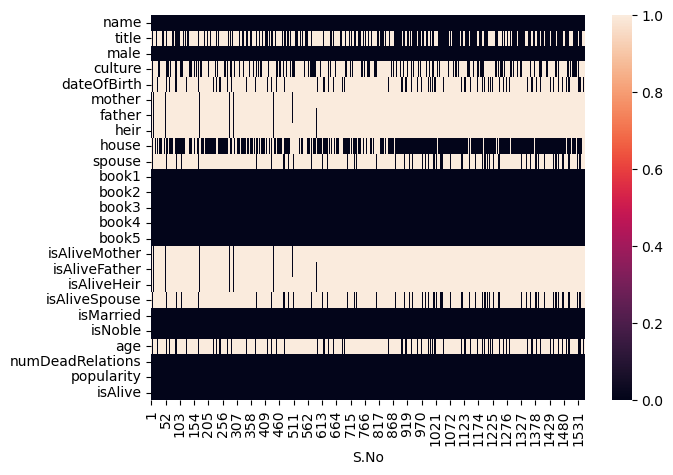

In [2562]:
# тепловая карта пропущенных значений
plt.figure(figsize=(7,5))
sns.heatmap(data.isna().transpose())

##### признак title

In [2563]:
temp = data.title.value_counts()
temp[temp>1].index

Index(['Ser', 'Maester', 'Archmaester', 'Lord', 'Septon', 'Winterfell', 'Lady',
       'King in the North', 'Septa', 'Princess',
       'Lord Commander of the Night's Watch', 'Cupbearer', 'Prince',
       'Grand Maester', 'Wisdom', 'Khal', 'King-Beyond-the-Wall',
       'Prince of Dragonstone', 'Last Hearth', 'Duskendale',
       'Lord Paramount of the Mander', 'Eyrie', 'Casterly Rock', 'Bloodrider',
       'Lord of the Tides', 'Bitterbridge', 'Harrenhal', 'Queen', 'Brother',
       'Starpike', 'Master of Coin', 'Crag', 'Stonehelm', 'Goodwife',
       'Khalakka', 'Karhold', 'Cerwyn', 'Coldmoat', 'Ashford',
       'Captain of the guard', 'Blackcrown', 'Golden Tooth', 'Good Master',
       'Hornwood', 'Lord Reaper of Pyke', 'Castellan', 'Riverrun', 'Steward',
       'Hand of the King', 'Yronwood', 'Knight', 'Prince of Dorne',
       'Stokeworth', 'KhalKo (formerly)', 'PrincessQueen', 'King'],
      dtype='object', name='title')

In [2564]:
# словарь из самых частых титулов расставим вручную
title_map = {'Ser':3, 'Maester':2, 'Archmaester':2, 'Lord':4, 'Septon':4, 'Winterfell':3, 'Lady':4,
       'King in the North':5, 'Septa':2, 'Princess':5,
       'Lord Commander of the Night\'s Watch':4, 'Cupbearer':1, 'Prince':5,
       'Grand Maester':2, 'Wisdom':2, 'Khal':5, 'King-Beyond-the-Wall':5,
       'Prince of Dragonstone':5, 'Last Hearth':3, 'Duskendale':3,
       'Lord Paramount of the Mander':4, 'Eyrie':3, 'Casterly Rock':3, 'Bloodrider':3,
       'Lord of the Tides':4, 'Bitterbridge':3, 'Harrenhal':3, 'Queen':5, 'Brother':1,
       'Starpike':3, 'Master of Coin':3, 'Crag':3, 'Stonehelm':3, 'Goodwife':1,
       'Khalakka':4, 'Karhold':3, 'Cerwyn':3, 'Coldmoat':3, 'Ashford':3,
       'Captain of the guard':3, 'Blackcrown':3, 'Golden Tooth':3, 'Good Master':1,
       'Hornwood':3, 'Lord Reaper of Pyke':4, 'Castellan':3, 'Riverrun':3, 'Steward':3,
       'Hand of the King':5, 'Yronwood':3, 'Knight':3, 'Prince of Dorne':5,
       'Stokeworth':3, 'KhalKo (formerly)':4, 'PrincessQueen':5, 'King':5}
data['title'] = data['title'].replace(title_map)
test['title'] = test['title'].replace(title_map)

In [2565]:
# остальные по маскам
mask1 = data.title.str.contains(r'lord|lady', case=False, regex=True, na=False)
mask2 = data.title.str.contains(r'knight|master', case=False, regex=True, na=False)
mask3 = data.title.str.contains(r'king|queen', case=False, regex=True, na=False)
data.loc[mask3, 'title'] = 5
data.loc[mask1, 'title'] = 4
data.loc[mask2, 'title'] = 3
# и остается 90 титулов, присвоим им величину значимости 2,5
data.loc[(~data.title.isna())&(~data.title.isin([1, 2, 3, 4, 5])), 'title'] = 2.5
# без титула - 0
data.title = data.title.fillna(0)

/tmp/ipykernel_50090/3385397568.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.title = data.title.fillna(0)


In [2566]:
# test
mask1 = test.title.str.contains(r'lord|lady', case=False, regex=True, na=False)
mask2 = test.title.str.contains(r'knight|master', case=False, regex=True, na=False)
mask3 = test.title.str.contains(r'king|queen', case=False, regex=True, na=False)
test.loc[mask3, 'title'] = 5
test.loc[mask1, 'title'] = 4
test.loc[mask2, 'title'] = 3
# и остается 90 титулов, присвоим им величину значимости 2,5
test.loc[(~test.title.isna())&(~test.title.isin([1, 2, 3, 4, 5])), 'title'] = 2.5
# без титула - 0
test.title = test.title.fillna(0)

/tmp/ipykernel_50090/3049547508.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test.title = test.title.fillna(0)


In [2567]:
temp = data.title.value_counts()
temp

title
0.0    840
3.0    387
4.0    101
2.5     90
2.0     70
5.0     54
1.0     15
Name: count, dtype: int64

##### признак culture

In [2568]:
# по маскам
data.loc[data.culture.isin(['Northmen', 'northmen', 'Northern mountain clans', 'Crannogmen']), 'culture'] = 'Север'
data.loc[data.culture.isin(['Rivermen', 'Riverlands']), 'culture'] = 'Речные земли'
data.loc[data.culture.isin(['Vale', 'Vale mountain clans', 'Sistermen', 'Valemen']), 'culture'] = 'Долина'
data.loc[data.culture.isin(['Ironborn', 'Ironmen', 'ironborn']), 'culture'] = 'Железные острова'
data.loc[data.culture.isin(['Stormlands', 'Stormlander']), 'culture'] = 'Штормовые земли'
data.loc[data.culture.isin(['Westerlands', 'Westerman', 'Westermen', 'westermen']), 'culture'] = 'Запад'
data.loc[data.culture.isin(['The Reach', 'Reachmen', 'Reach']), 'culture'] = 'Простор'
data.loc[data.culture.isin(['Dornish', 'Dornishmen', 'Dorne']), 'culture'] = 'Дорн'
data.loc[data.culture.isin(['free folk', 'Free Folk', 'Free folk', 'Wildling', 'Wildlings']), 'culture'] = 'Одичалые'
data.loc[data.culture.isin(['Dothraki']), 'culture'] = 'Дотракийцы'
data.loc[data.culture.isin(['Summer Islands', 'Summer Isles', 'Summer Islander']), 'culture'] = 'Летние острова'
data.loc[data.culture.isin(['Qohor', 'Pentoshi', 'Tyroshi']), 'culture'] = 'Эссос Запад'
data.loc[data.culture.isin(['Ghiscari', 'Ghiscaricari', 'Astapori', 'Meereenese', 'Meereen', 'Astapor']), 'culture'] = 'Залив работорговцев'
data.loc[data.culture.isin(['Asshai\'i', 'Asshai']), 'culture'] = 'Асшай'
data.loc[data.culture.isin(['Lysene', 'Lyseni']), 'culture'] = 'Лис'
data.loc[data.culture.isin(['Andal', 'Andals']), 'culture'] = 'Андалы'
data.loc[data.culture.isin(['Braavos', 'Braavosi']), 'culture'] = 'Браавос'
data.loc[data.culture.isin(['Myrish']), 'culture'] = 'Мир'
data.loc[data.culture.isin(['Norvoshi', 'Norvos']), 'culture'] = 'Норвош'
data.loc[data.culture.isin(['Qartheen', 'Qarth']), 'culture'] = 'Кварт'
data.loc[data.culture.isin(['westeros', 'westerosi', 'Westeros']), 'culture'] = 'Вестерос'
data.loc[data.culture.isin(['Lhazarene', 'Lhazareen']), 'culture'] = 'Лхазаряне'
data.loc[data.culture.isin(['Valyrian']), 'culture'] = 'Валирия'
data.loc[data.culture.isin(['First Men']), 'culture'] = 'Первые люди'
data.loc[data.culture.isin(['Rhoynar']), 'culture'] = 'Ройнары'
data.loc[data.culture.isin(['Naathi']), 'culture'] = 'Наат'
data.loc[data.culture.isin(['Ibbenese']), 'culture'] = 'Иббен'

In [2569]:
# test
test.loc[test.culture.isin(['Northmen', 'northmen', 'Northern mountain clans', 'Crannogmen']), 'culture'] = 'Север'
test.loc[test.culture.isin(['Rivermen', 'Riverlands']), 'culture'] = 'Речные земли'
test.loc[test.culture.isin(['Vale', 'Vale mountain clans', 'Sistermen', 'Valemen']), 'culture'] = 'Долина'
test.loc[test.culture.isin(['Ironborn', 'Ironmen', 'ironborn']), 'culture'] = 'Железные острова'
test.loc[test.culture.isin(['Stormlands', 'Stormlander']), 'culture'] = 'Штормовые земли'
test.loc[test.culture.isin(['Westerlands', 'Westerman', 'Westermen', 'westermen']), 'culture'] = 'Запад'
test.loc[test.culture.isin(['The Reach', 'Reachmen', 'Reach']), 'culture'] = 'Простор'
test.loc[test.culture.isin(['Dornish', 'Dornishmen', 'Dorne']), 'culture'] = 'Дорн'
test.loc[test.culture.isin(['free folk', 'Free Folk', 'Free folk', 'Wildling', 'Wildlings']), 'culture'] = 'Одичалые'
test.loc[test.culture.isin(['Dothraki']), 'culture'] = 'Дотракийцы'
test.loc[test.culture.isin(['Summer Islands', 'Summer Isles', 'Summer Islander']), 'culture'] = 'Летние острова'
test.loc[test.culture.isin(['Qohor', 'Pentoshi', 'Tyroshi']), 'culture'] = 'Эссос Запад'
test.loc[test.culture.isin(['Ghiscari', 'Ghiscaricari', 'Astapori', 'Meereenese', 'Meereen', 'Astapor']), 'culture'] = 'Залив работорговцев'
test.loc[test.culture.isin(['Asshai\'i', 'Asshai']), 'culture'] = 'Асшай'
test.loc[test.culture.isin(['Lysene', 'Lyseni']), 'culture'] = 'Лис'
test.loc[test.culture.isin(['Andal', 'Andals']), 'culture'] = 'Андалы'
test.loc[test.culture.isin(['Braavos', 'Braavosi']), 'culture'] = 'Браавос'
test.loc[test.culture.isin(['Myrish']), 'culture'] = 'Мир'
test.loc[test.culture.isin(['Norvoshi', 'Norvos']), 'culture'] = 'Норвош'
test.loc[test.culture.isin(['Qartheen', 'Qarth']), 'culture'] = 'Кварт'
test.loc[test.culture.isin(['westeros', 'westerosi', 'Westeros']), 'culture'] = 'Вестерос'
test.loc[test.culture.isin(['Lhazarene', 'Lhazareen']), 'culture'] = 'Лхазаряне'
test.loc[test.culture.isin(['Valyrian']), 'culture'] = 'Валирия'
test.loc[test.culture.isin(['First Men']), 'culture'] = 'Первые люди'
test.loc[test.culture.isin(['Rhoynar']), 'culture'] = 'Ройнары'
test.loc[test.culture.isin(['Naathi']), 'culture'] = 'Наат'
test.loc[test.culture.isin(['Ibbenese']), 'culture'] = 'Иббен'

##### признаки dateOfBirth и age

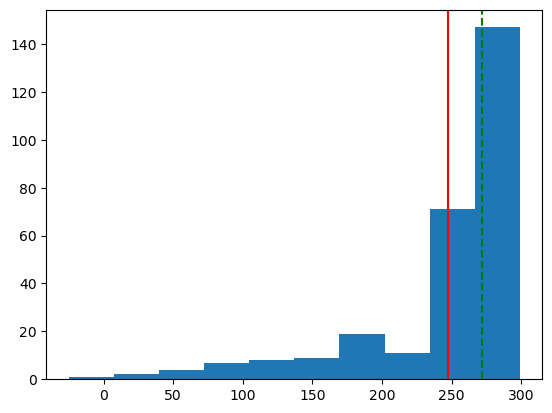

In [2570]:
mean_Age = np.mean(data['dateOfBirth'].dropna())
median_Age = data['dateOfBirth'].dropna().median()

plt.hist(data['dateOfBirth'])

plt.axvline(x=mean_Age, color='r', linestyle = '-', label='mean')
plt.axvline(x=median_Age, color='g', linestyle = '--', label='median')

plt.show()

In [2571]:
data.fillna({'dateOfBirth': data.dateOfBirth.median()}, inplace=True)

In [2572]:
data.drop('age', axis=1, inplace=True)
test.drop('age', axis=1, inplace=True)

##### признак house

In [2573]:
temp = data.house.str.replace(r'house ', '', case=False).value_counts()
temp[temp>1].index

Index(['Frey', 'Night's Watch', 'Stark', 'Targaryen', 'Lannister', 'Tyrell',
       'Greyjoy', 'Osgrey', 'Faith of the Seven', 'Hightower',
       ...
       'Morrigen', 'Wells', 'Lonmouth', 'Blackberry', 'Clifton',
       'Kenning of Kayce', 'Humble', 'Reed', 'Uffering', 'Allyrion'],
      dtype='object', name='house', length=165)

In [2574]:
data.house = data.house.str.replace(r'house ', '', case=False)

In [2575]:
#заполнение дома по имени
for j, i in data.iterrows():
    if pd.isnull(i['house']):
        if i['name'].split(' ')[-1] in data['house'].values:
            data.loc[j, 'house']=i['name'].split(' ')[-1]

In [2576]:
#заполняем поле дом по отцу и наследнику
data.loc[data.house.isna()&(~data.father.isna()), 'house'] = \
    data.loc[data.house.isna()&(~data.father.isna()), 'father'].apply(lambda x: x.split(' ')[-1])
data.loc[data.house.isna()&(~data.heir.isna()), 'house'] = \
    data.loc[data.house.isna()&(~data.heir.isna()), 'heir'].apply(lambda x: x.split(' ')[-1])

In [2577]:
data.house.isna().sum()

340

In [2578]:
temp = data.house.str.replace(r'house ', '', case=False).value_counts()
temp[temp>1].index

Index(['Frey', 'Night's Watch', 'Stark', 'Targaryen', 'Lannister', 'Tyrell',
       'Greyjoy', 'Osgrey', 'Faith of the Seven', 'Botley',
       ...
       'Morrigen', 'Reed', 'Hetherspoon', 'Spicer', 'Charlton', 'Stormcrows',
       'Cerwyn', 'Uffering', 'Flint of Widow's Watch', 'Slynt'],
      dtype='object', name='house', length=169)

In [2579]:
land_dict = {'Таргариены': ['Targaryen'], 
             'Разбойники': ['Brotherhood without banners', 'Brotherhood Without Banners', 'Kingswood Brotherhood'],
             'Королевские земли': ['Faith of the Seven', 'Alchemists\' Guild''Slynt', 'Sunglass', 'Baratheon of King\'s Landing', 'Rosby', 'Hollard', 'Kingsguard', 'Darklyn', 'Crabb', 'Stokeworth', 'Farring', 'Staunton', 'Chataya\'s brothel'],
             'Наёмники': ['Second Sons', 'Brave Companions', 'Stormcrows'],
             'Север': ['Reed', 'Manderly', 'Hornwood', 'Cerwyn', 'Ryswell', 'Stout', 'Flint of Widow\'s Watch', 'Cassel', 'Locke', 'Glover', 'Mormont', 'Umber', 'Karstark', 'Stark', 'Bolton', 'Tallhart'],
             'Речные земли': ['Moon Brothers', 'Charlton', 'Heddle', 'Ryger', 'Piper', 'Nayland', 'Smallwood', 'Butterwell', 'Blackwood', 'Strong', 'Vypren', 'Mooton', 'Frey of Riverrun', 'Vance of Wayfarer\'s Rest', 'Vance', 'Lothston', 'Goodbrook', 'Darry', 'Vance of Atranta', 'Mallister', 'Haigh', 'Whent', 'Frey', 'Bracken', 'Tully', 'Paege', 'Penny'],
             'Долина': ['Tollett', 'Belmore', 'Burned Men', 'Lynderly', 'Hardyng', 'Grafton', 'Royce of the Gates of the Moon', 'Corbray', 'Hunter', 'Royce', 'Redfort', 'Baelish', 'Arryn', 'Waynwood', 'Stone Crows'],
             'Железные острова': ['Humble', 'Codd', 'Wynch', 'Shepherd', 'Kenning of Harlaw', 'Sharp', 'Farwynd of the Lonely Light', 'Drowned men', 'Goodbrother', 'Ironmaker', 'Harlaw', 'Greyjoy', 'Botley', 'Drumm'],
             'Штормовые земли': ['Blackberry', 'Lonmouth', 'Morrigen', 'Fell', 'Caron', 'Penrose', 'Connington', 'Tarth', 'Baratheon', 'Swann', 'Estermont', 'Baratheon of Dragonstone', 'Seaworth', 'Wylde', 'Velaryon'],
             'Запад': ['Kenning of Kayce', 'Clifton', 'Prester', 'Hetherspoon', 'Spicer', 'Lydden', 'Stackspear', 'Marbrand', 'Lefford', 'Clegane', 'Swyft', 'Plumm', 'Lannister', 'Crakehall', 'Westerling', 'Brax'],
             'Простор': ['Uffering', 'Peake', 'Willum', 'Tarly', 'Inchfield', 'Wythers', 'Meadows', 'Serry', 'Bulwer', 'Oakheart', 'Costayne', 'Fossoway of Cider Hall', 'Ambrose', 'Crane', 'Webber', 'Ashford', 'Norcross', 'Caswell', 'Redwyne', 'Beesbury', 'Tyrell', 'Osgrey', 'Hightower', 'Florent'],
             'Дорн': ['Allyrion', 'Wells', 'Jordayne', 'Yronwood', 'Santagar', 'Dalt', 'Uller', 'Blackmont', 'Dayne', 'Manwoody', 'Qorgyle', 'Martell'],
             'Ночной дозор': ['Night\'s Watch'],
             'Залив работорговцев': ['of Galare', 'of Loraq'],
             'Браавос': ['Happy Port'],
             'Эссос Запад': ['Kingdom of the Three Daughters']
}

In [2580]:
data['land'] = '0'
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Targaryen']), 'land'] = 'Таргариены'
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Brotherhood without banners', 'Brotherhood Without Banners', \
    'Kingswood Brotherhood']), 'land'] = 'Разбойники'
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Faith of the Seven', 'Alchemists\' Guild''Slynt', 'Sunglass', \
    'Baratheon of King\'s Landing', 'Rosby', 'Hollard', 'Kingsguard', 'Darklyn', 'Crabb', 'Stokeworth', \
        'Farring', 'Staunton', 'Chataya\'s brothel']), 'land'] = 'Королевские земли'
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Second Sons', 'Brave Companions', 'Stormcrows']), 'land'] = 'Наёмники'
#север
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Reed', 'Manderly', 'Hornwood', 'Cerwyn', 'Ryswell', 'Stout', 'Flint of Widow\'s Watch', \
    'Cassel', 'Locke', 'Glover', 'Mormont', 'Umber', 'Karstark', 'Stark', 'Bolton', 'Tallhart']), 'land'] = 'Север'
#речные земли
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Moon Brothers', 'Charlton', 'Heddle', 'Ryger', 'Piper', 'Nayland', 'Smallwood', \
    'Butterwell', 'Blackwood', 'Strong', 'Vypren', 'Mooton', 'Frey of Riverrun', 'Vance of Wayfarer\'s Rest', \
    'Vance', 'Lothston', 'Goodbrook', 'Darry', 'Vance of Atranta', 'Mallister', 'Haigh', 'Whent', 'Frey', 'Bracken', \
    'Tully', 'Paege', 'Penny']), 'land'] = 'Речные земли'
#долина
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Tollett', 'Belmore', 'Burned Men', 'Lynderly', 'Hardyng', 'Grafton', \
    'Royce of the Gates of the Moon', 'Corbray', 'Hunter', 'Royce', 'Redfort', \
    'Baelish', 'Arryn', 'Waynwood', 'Stone Crows']), 'land'] = 'Долина'
#железные острова
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Humble', 'Codd', 'Wynch', 'Shepherd', 'Kenning of Harlaw', 'Sharp', \
    'Farwynd of the Lonely Light', 'Drowned men', 'Goodbrother', 'Ironmaker', 'Harlaw', \
    'Greyjoy', 'Botley', 'Drumm']), 'land'] = 'Железные острова'
#штормовые земли
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Blackberry', 'Lonmouth', 'Morrigen', 'Fell', 'Caron', 'Penrose', 'Connington', 'Tarth', \
    'Baratheon', 'Swann', 'Estermont', 'Baratheon of Dragonstone', 'Seaworth', 'Wylde', \
        'Velaryon']), 'land'] = 'Штормовые земли'
#запад
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Kenning of Kayce', 'Clifton', 'Prester', \
    'Hetherspoon', 'Spicer', 'Lydden', 'Stackspear', 'Marbrand', 'Lefford', 'Clegane', 'Swyft', 'Plumm', \
        'Lannister', 'Crakehall', 'Westerling', 'Brax']), 'land'] = 'Запад'
#простор
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Uffering', 'Peake', 'Willum', 'Tarly', 'Inchfield', 'Wythers', 'Meadows', 'Serry', \
    'Bulwer', 'Oakheart', 'Costayne', 'Fossoway of Cider Hall', 'Ambrose', 'Crane', 'Webber', 'Ashford', 'Norcross', \
    'Caswell', 'Redwyne', 'Beesbury', 'Tyrell', 'Osgrey', 'Hightower', 'Florent']), 'land'] = 'Простор'
#дорн
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Allyrion', 'Wells', 'Jordayne', 'Yronwood', 'Santagar', 'Dalt', 'Uller', 'Blackmont', \
    'Dayne', 'Manwoody', 'Qorgyle', 'Martell']), 'land'] = 'Дорн'
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Night\'s Watch']), 'land'] = 'Ночной дозор'
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['of Galare', 'of Loraq']), 'land'] = 'Залив работорговцев'
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Happy Port']), 'land'] = 'Браавос'
data.loc[data.house.str.replace(r'house ', '', case=False).isin(['Kingdom of the Three Daughters']), 'land'] = 'Эссос Запад'

In [2581]:
#если нет, заполняем значением столбца культура
data.loc[data.land=='0', 'land'] = data.loc[data.land=='0', 'culture']

In [2582]:
#test
test.loc[test.house.isna()&(~test.father.isna()), 'house'] = \
    test.loc[test.house.isna()&(~test.father.isna()), 'father'].apply(lambda x: x.split(' ')[-1])
test.loc[test.house.isna()&(~test.heir.isna()), 'house'] = \
    test.loc[test.house.isna()&(~test.heir.isna()), 'heir'].apply(lambda x: x.split(' ')[-1])
    
test['land'] = '0'
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Targaryen']), 'land'] = 'Таргариены'
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Brotherhood without banners', 'Brotherhood Without Banners', \
    'Kingswood Brotherhood']), 'land'] = 'Разбойники'
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Faith of the Seven', 'Alchemists\' Guild''Slynt', 'Sunglass', \
    'Baratheon of King\'s Landing', 'Rosby', 'Hollard', 'Kingsguard', 'Darklyn', 'Crabb', 'Stokeworth', \
        'Farring', 'Staunton', 'Chataya\'s brothel']), 'land'] = 'Королевские земли'
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Second Sons', 'Brave Companions', 'Stormcrows']), 'land'] = 'Наёмники'
#север
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Reed', 'Manderly', 'Hornwood', 'Cerwyn', 'Ryswell', 'Stout', 'Flint of Widow\'s Watch', \
    'Cassel', 'Locke', 'Glover', 'Mormont', 'Umber', 'Karstark', 'Stark', 'Bolton', 'Tallhart']), 'land'] = 'Север'
#речные земли
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Moon Brothers', 'Charlton', 'Heddle', 'Ryger', 'Piper', 'Nayland', 'Smallwood', \
    'Butterwell', 'Blackwood', 'Strong', 'Vypren', 'Mooton', 'Frey of Riverrun', 'Vance of Wayfarer\'s Rest', \
    'Vance', 'Lothston', 'Goodbrook', 'Darry', 'Vance of Atranta', 'Mallister', 'Haigh', 'Whent', 'Frey', 'Bracken', \
    'Tully', 'Paege', 'Penny']), 'land'] = 'Речные земли'
#долина
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Tollett', 'Belmore', 'Burned Men', 'Lynderly', 'Hardyng', 'Grafton', \
    'Royce of the Gates of the Moon', 'Corbray', 'Hunter', 'Royce', 'Redfort', \
    'Baelish', 'Arryn', 'Waynwood', 'Stone Crows']), 'land'] = 'Долина'
#железные острова
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Humble', 'Codd', 'Wynch', 'Shepherd', 'Kenning of Harlaw', 'Sharp', \
    'Farwynd of the Lonely Light', 'Drowned men', 'Goodbrother', 'Ironmaker', 'Harlaw', \
    'Greyjoy', 'Botley', 'Drumm']), 'land'] = 'Железные острова'
#штормовые земли
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Blackberry', 'Lonmouth', 'Morrigen', 'Fell', 'Caron', 'Penrose', 'Connington', 'Tarth', \
    'Baratheon', 'Swann', 'Estermont', 'Baratheon of Dragonstone', 'Seaworth', 'Wylde', \
        'Velaryon']), 'land'] = 'Штормовые земли'
#запад
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Kenning of Kayce', 'Clifton', 'Prester', \
    'Hetherspoon', 'Spicer', 'Lydden', 'Stackspear', 'Marbrand', 'Lefford', 'Clegane', 'Swyft', 'Plumm', \
        'Lannister', 'Crakehall', 'Westerling', 'Brax']), 'land'] = 'Запад'
#простор
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Uffering', 'Peake', 'Willum', 'Tarly', 'Inchfield', 'Wythers', 'Meadows', 'Serry', \
    'Bulwer', 'Oakheart', 'Costayne', 'Fossoway of Cider Hall', 'Ambrose', 'Crane', 'Webber', 'Ashford', 'Norcross', \
    'Caswell', 'Redwyne', 'Beesbury', 'Tyrell', 'Osgrey', 'Hightower', 'Florent']), 'land'] = 'Простор'
#дорн
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Allyrion', 'Wells', 'Jordayne', 'Yronwood', 'Santagar', 'Dalt', 'Uller', 'Blackmont', \
    'Dayne', 'Manwoody', 'Qorgyle', 'Martell']), 'land'] = 'Дорн'
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Night\'s Watch']), 'land'] = 'Ночной дозор'
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['of Galare', 'of Loraq']), 'land'] = 'Залив работорговцев'
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Happy Port']), 'land'] = 'Браавос'
test.loc[test.house.str.replace(r'house ', '', case=False).isin(['Kingdom of the Three Daughters']), 'land'] = 'Эссос Запад'

test.loc[test.land=='0', 'land'] = test.loc[test.land=='0', 'culture']

##### Признаки isAliveMother, isAliveFather, isAliveHeir, isAliveSpouse

In [2583]:
# меняем "умер" на 1, а "жив" на 0
transform_col = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']
for i in transform_col:
	index_alive = data.loc[data[i]==1].index
	data.loc[data[i]==0, i] = 1
	data.loc[index_alive, i] = 0
	data.loc[data[i].isna(), i] = 0
 
# количество умерших родственников
data['dead_family'] = 0
for _, i in data.iterrows():
    data['dead_family'] = (data['isAliveMother']+data['isAliveFather']+data['isAliveHeir']+data['isAliveSpouse'])
    
# общее количество смертей вокруг персонажа
data['dead_connections'] = data['numDeadRelations'] + data['dead_family']

In [2584]:
# test
transform_col = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']
for i in transform_col:
	index_alive = test.loc[test[i]==1].index
	test.loc[test[i]==0, i] = 1
	test.loc[index_alive, i] = 0
	test.loc[test[i].isna(), i] = 0
 
# количество умерших родственников
test['dead_family'] = 0
for _, i in test.iterrows():
    test['dead_family'] = (test['isAliveMother']+test['isAliveFather']+test['isAliveHeir']+test['isAliveSpouse'])
    
# общее количество смертей вокруг персонажа
test['dead_connections'] = test['numDeadRelations'] + test['dead_family']

<Axes: xlabel='S.No'>

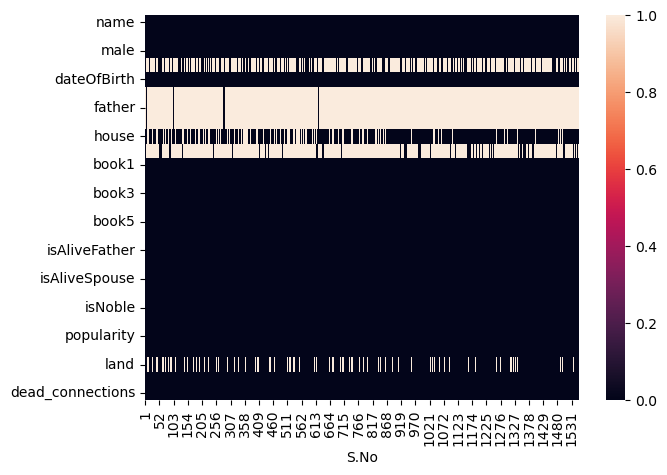

In [2585]:
# тепловая карта пропущенных значений
plt.figure(figsize=(7,5))
sns.heatmap(data.isna().transpose())

In [2586]:
data.describe()

,title,male,dateOfBirth,book1,book2,book3,book4,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,numDeadRelations,popularity,isAlive,dead_family,dead_connections
count,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000
mean,1.422608,0.590880,267.619139,0.138728,0.327553,0.431599,0.562620,0.330122,0.003854,0.010918,0.004496,0.026975,0.128452,0.439306,0.187540,0.062400,0.778420,0.046243,0.233783
std,1.634191,0.491829,27.655486,0.345774,0.469472,0.495458,0.496223,0.470408,0.061977,0.103953,0.066922,0.162062,0.334700,0.496462,1.114648,0.121416,0.415443,0.244043,1.253505
min,0.000000,0.000000,-25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,272.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013378,1.000000,0.000000,0.000000
50%,0.000000,1.000000,272.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023411,1.000000,0.000000,0.000000
75%,3.000000,1.000000,272.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.063545,1.000000,0.000000,0.000000
max,5.000000,1.000000,299.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.000000,1.000000,1.000000,2.000000,16.000000


culture и land будут закодированы

#### **Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


In [2587]:
data['IsPopular'] = data.popularity.apply(lambda x: 1 if x>=0.5 else 0)
data['boolDeadRelations'] = data.numDeadRelations.apply(lambda x: 1 if x>0 else 0)

In [2588]:
test['IsPopular'] = test.popularity.apply(lambda x: 1 if x>=0.5 else 0)
test['boolDeadRelations'] = test.numDeadRelations.apply(lambda x: 1 if x>0 else 0)

признак culture упрощён ранее

#### **Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

In [2589]:
# удаление неинформативных столбцов
data.drop(['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
           'mother', 'father', 'heir', 'spouse', 'house', 'name', 'numDeadRelations', 'popularity', 'isNoble'], axis=1, inplace=True)
test.drop(['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
           'mother', 'father', 'heir', 'spouse', 'house', 'name', 'numDeadRelations', 'popularity', 'isNoble'], axis=1, inplace=True)

#### **Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

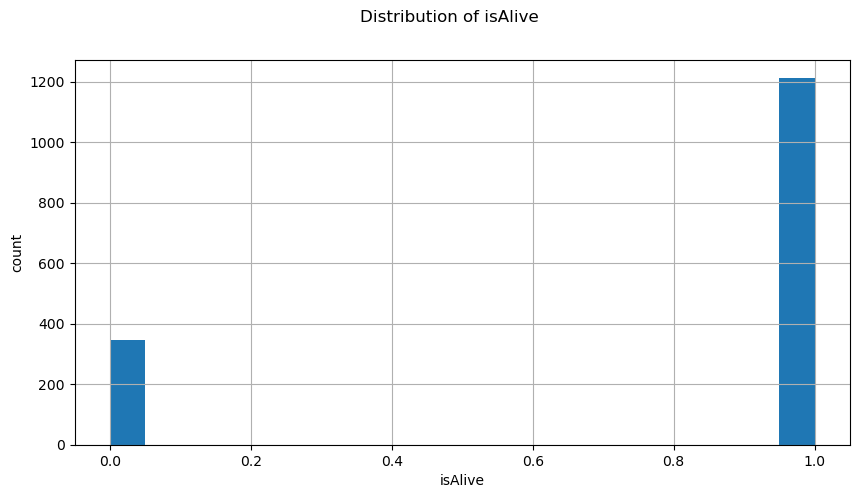

In [2590]:
plt.figure(figsize = (10, 5))

data['isAlive'].hist(density=False, bins=20)
plt.ylabel('count')
plt.xlabel('isAlive')

plt.suptitle('Distribution of isAlive')
plt.show()

По классам датасет не сбалансирован

#### **Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [2591]:
cat_columns = ['culture', 'land']
encoder = OneHotEncoder(sparse_output=False)

one_hot = encoder.fit_transform(data[cat_columns])
one_hot_df = pd.DataFrame(one_hot, columns=encoder.get_feature_names_out(cat_columns), index=data.index)
data = pd.concat([data, one_hot_df], axis=1)
data.drop(['culture', 'land', 'culture_nan', 'land_nan'], axis=1, inplace=True)

In [2592]:
one_hot = encoder.fit_transform(test[cat_columns])
one_hot_df = pd.DataFrame(one_hot, columns=encoder.get_feature_names_out(cat_columns), index=test.index)
test = pd.concat([test, one_hot_df], axis=1)
test.drop(['culture', 'land', 'culture_nan', 'land_nan'], axis=1, inplace=True)

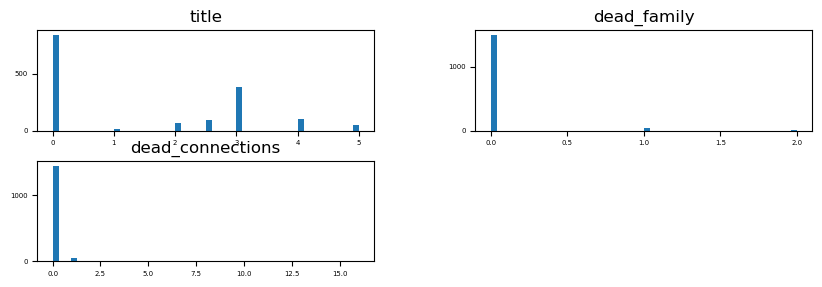

In [2593]:
data[['title', 'dead_family', 'dead_connections']].hist(figsize=(10, 3), bins=50,xlabelsize=5, ylabelsize=5, grid=False);

Text(0.5, 1.0, 'Тепловая карта корреляции')

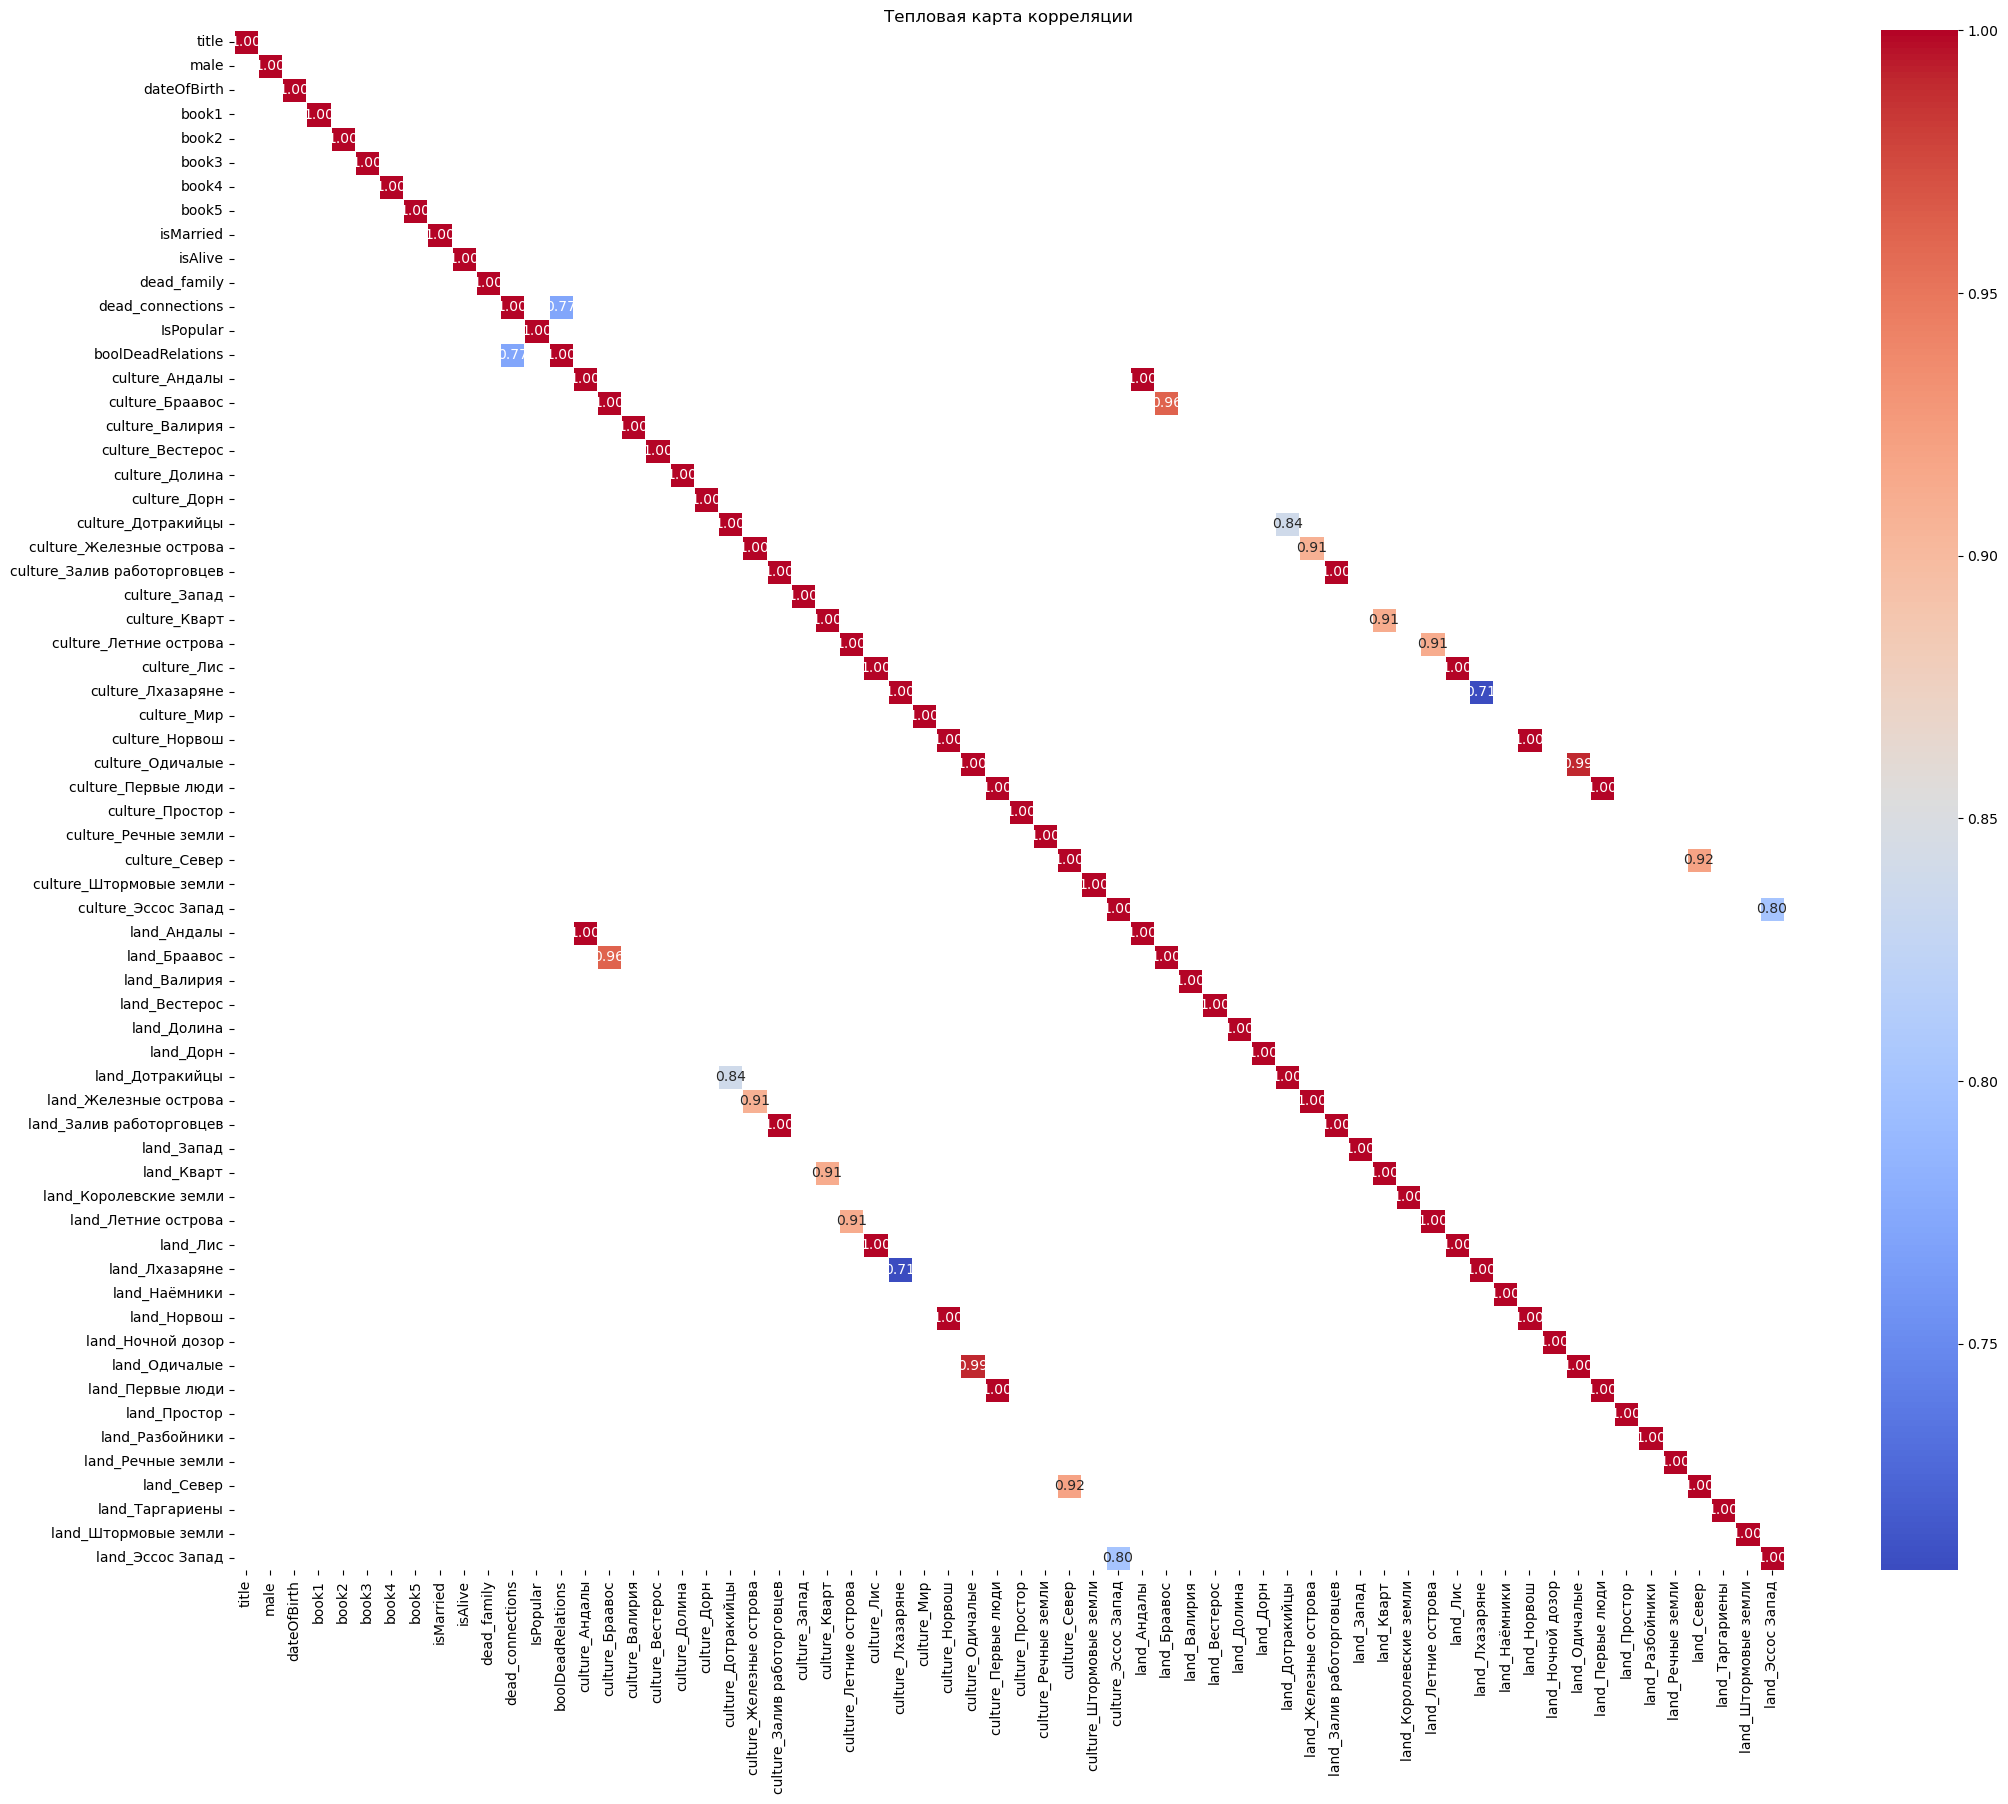

In [2594]:
df_corr = data.corr()

fig = plt.figure(figsize = (25,20))

ax = sns.heatmap(df_corr[0.7<=df_corr.abs()], fmt='.2f', linewidths=.4, cmap='coolwarm', annot=True)

ax.set_title('Тепловая карта корреляции')

In [2595]:
#список столбцов в порядке возрастания корреляции c целевой переменной
df_corr_clean = df_corr.copy()
df_corr_clean.isAlive = abs(df_corr_clean.isAlive)
list_corr_sort = pd.DataFrame(df_corr_clean.sort_values('isAlive').index, columns=['name']).reset_index()

In [2596]:
list_corr_clean = []

for i in list_corr_sort.name: # имена всех столбцов
    temp = df_corr[abs(df_corr[i])>0.7][i].index # имена столбцов c сильной корреляцией между собой
    temp = pd.DataFrame(temp, columns=['name']) # таблица c именами скоррелированных столбцов
    temp = temp.merge(list_corr_sort, on='name', how='left') # добавление номера в ранжированном списке по корреляции c целевой переменнной
    list_corr_clean.append(temp.sort_values('index', ascending=False).iloc[0, 0]) # сортировка по корреляции c целевой переменной
    
list_corr_clean = list(set(list_corr_clean)) # удаление дубликатов из финального списка столбцов

In [2597]:
data = data[list_corr_clean]

In [2598]:
#test
list_corr_clean.remove('isAlive')
for i in ['land_Первые люди', 'land_Норвош', 'land_Эссос Запад', 'culture_Андалы', 'land_Андалы']:
    test[i] = 0
test = test[list_corr_clean]

#### **Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

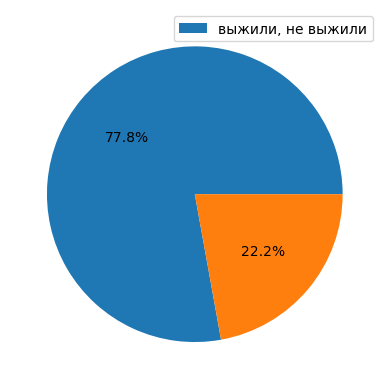

In [2599]:
# Готовим данные для графика
df = data['isAlive'].value_counts()

# Строим круговую диаграмму
plt.pie(df, autopct='%1.1f%%')

plt.legend(['выжили, не выжили'])

plt.show()

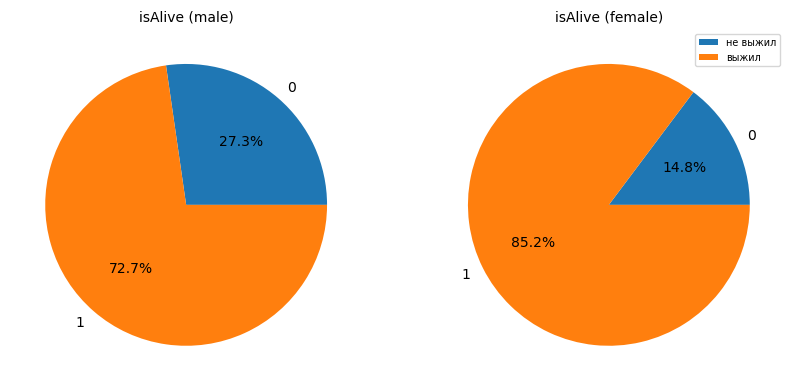

In [2600]:
# female - 0, male - 1
data_1 = data[data['male']== 1]['isAlive'].value_counts().sort_values()
data_2 = data[data['male']== 0]['isAlive'].value_counts().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

ax1.pie(data_1.values, labels=data_1.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(data_2.values, labels=data_2.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('isAlive (male)', fontsize=10)
ax2.set_title('isAlive (female)', fontsize=10)

plt.legend(['не выжил', 'выжил'], fontsize=7)

plt.show()

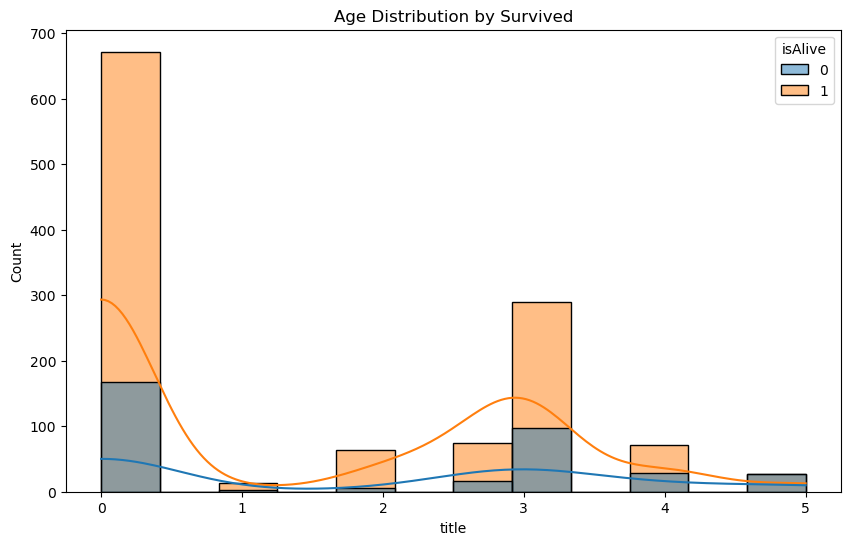

In [2601]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='title', kde=True, hue='isAlive')
plt.title('Age Distribution by Survived')
plt.show()

#### **Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [2602]:
X = data.drop('isAlive', axis=1).values
y = data.isAlive.values

#### **Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [2603]:
from sklearn.model_selection import train_test_split

In [2604]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [2605]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [2606]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [2607]:
rm = 19

In [2608]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=1, random_state=rm)

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Аналогичным образом обучите остальные модели и сделайте предсказания на тестовой выборке.

In [2609]:
#AdaBoostClassifier
AdaBoost = AdaBoostClassifier(random_state=rm)
AdaBoost.fit(X_train, y_train)

#RandomForestClassifier
rf = RandomForestClassifier(random_state=rm)
rf.fit(X_train, y_train)

#GaussianProcessClassifier
gpc = GaussianProcessClassifier(random_state=rm)
gpc.fit(X_train, y_train)

#GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

#KNeighborsClassifier
knc = KNeighborsClassifier()
knc.fit(X_train, y_train)

#SVC
svc = SVC(random_state=rm)
svc.fit(X_train, y_train)

#DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=rm)
dtc.fit(X_train, y_train)

/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


DecisionTreeClassifier(random_state=19)

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [2610]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [2611]:
# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8205


Аналогичным образом посчитайте метрику accuracy для остальных моделей

In [2612]:
y_pred = AdaBoost.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy AdaBoostClassifier: %.4f" % accuracy)

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy RandomForestClassifier: %.4f" % accuracy)

y_pred = gpc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy GaussianProcessClassifier: %.4f" % accuracy)

y_pred = gnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy GaussianNB: %.4f" % accuracy)

y_pred = knc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy KNeighborsClassifier: %.4f" % accuracy)

y_pred = svc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy SVC: %.4f" % accuracy)

y_pred = dtc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy DecisionTreeClassifier: %.4f" % accuracy)

Accuracy AdaBoostClassifier: 0.8365
Accuracy RandomForestClassifier: 0.7628
Accuracy GaussianProcessClassifier: 0.8237
Accuracy GaussianNB: 0.2981
Accuracy KNeighborsClassifier: 0.8013
Accuracy SVC: 0.8109
Accuracy DecisionTreeClassifier: 0.7179


In [2613]:
data.columns

Index(['land_Первые люди', 'land_Разбойники', 'land_Долина', 'book1',
       'land_Норвош', 'land_Таргариены', 'male', 'land_Наёмники',
       'culture_Железные острова', 'land_Речные земли', 'culture_Речные земли',
       'land_Эссос Запад', 'dead_family', 'land_Андалы', 'land_Лхазаряне',
       'dead_connections', 'book4', 'land_Одичалые', 'land_Королевские земли',
       'culture_Летние острова', 'dateOfBirth', 'land_Дорн', 'culture_Запад',
       'culture_Дорн', 'isMarried', 'culture_Вестерос', 'land_Простор',
       'land_Ночной дозор', 'land_Вестерос', 'book3',
       'culture_Штормовые земли', 'IsPopular', 'book2', 'land_Север',
       'isAlive', 'land_Запад', 'culture_Долина', 'culture_Простор',
       'land_Валирия', 'culture_Валирия', 'culture_Лис',
       'land_Штормовые земли', 'land_Браавос', 'land_Дотракийцы', 'book5',
       'title', 'land_Кварт', 'land_Залив работорговцев', 'culture_Мир'],
      dtype='object')

Выберите лучшую модель.

In [2618]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', LogisticRegression(random_state=rm))
])

# Сетка параметров
param_grid = {
    'model__penalty': ['l1', 'l2', 'elasticnet', None],
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver': ['saga', 'liblinear'],
    'model__l1_ratio': [0.3, 0.5, 0.7],
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [100, 200]
}

# Создаем GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Запуск поиска
grid_search.fit(X_train, y_train)

# Лучшие параметры
print("Best parameters:", grid_search.best_params_)
best_modellr = grid_search.best_estimator_
print("Accuracy : %.4f" % accuracy_score(y_test, best_modellr.predict(X_test)))

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Best parameters: {'model__C': 1, 'model__class_weight': None, 'model__l1_ratio': 0.3, 'model__max_iter': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Accuracy : 0.8301


/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
720 fits failed out of a total of 2880.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------

In [2619]:
param_grid = {
    'n_restarts_optimizer': np.arange(0, 10),
    'max_iter_predict': np.arange(80, 200, 30),
    'warm_start': [True],
    'multi_class': ['one_vs_rest', 'one_vs_one']
}
gridsearch = GridSearchCV(gpc, param_grid, refit=True, scoring='accuracy', n_jobs=-1)
gridsearch.fit(X_train, y_train)
print(gridsearch.best_params_)
best_modelgpc = gridsearch.best_estimator_
print("Accuracy : %.4f" % accuracy_score(y_test, best_modelgpc.predict(X_test)))

{'max_iter_predict': 80, 'multi_class': 'one_vs_rest', 'n_restarts_optimizer': 0, 'warm_start': True}
Accuracy : 0.8237


In [2620]:
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'n_estimators': [200],
    'max_depth': np.arange(1, 10),
    'min_samples_split': np.arange(2, 10),
    'min_samples_leaf': np.arange(1, 10)
}
gridsearch = GridSearchCV(rf, param_grid, refit=True, scoring='accuracy', n_jobs=-1)
gridsearch.fit(X_train, y_train)
print(gridsearch.best_params_)
best_modelrf = gridsearch.best_estimator_
print("Accuracy : %.4f" % accuracy_score(y_test, best_modelrf.predict(X_test)))

{'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 200}
Accuracy : 0.8141


/home/alena/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [ ]:
#!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

In [2625]:
submission = pd.read_csv("submission.csv", index_col='S.No')

In [2626]:
y_pred = best_modelrf.predict(test)
submission.isAlive = y_pred
submission

/home/alena/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,isAlive
S.No,
1558,0
1559,1
1560,1
1561,1
1562,1
...,...
1942,1
1943,1
1944,1


In [2627]:
submission.isAlive.value_counts()

isAlive
1    357
0     32
Name: count, dtype: int64

Как сохранить измененный Pandas DataFrame в csv файл:

In [2628]:
submission.to_csv("new_submission.csv", index=False)

Accuracy 0.686